In [ ]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec




We store the links to the data set. The data set includes solar energy related data.

In [7]:
# ── URL LISTS ────────────────────────────────────────────────────────────────
# Files to stack VERTICALLY (meter data — same columns, different time periods)
meter_urls = [
    "https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data.csv",
    "https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_meter_15m_data_2024.csv",
]

# Files to stack VERTICALLY (irradiance data — same columns, different time periods)
irradiance_urls = [
    "https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_irradiance_data.csv",
    "https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_irradiance_data_2024.csv",
]

environment_urls = [
    'https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_environment_data.csv',
    'https://oedi-data-lake.s3.amazonaws.com/pvdaq/2023-solar-data-prize/2107_OEDI/data/2107_environment_data_2024.csv'
]

TIMESTAMP_COL = "measured_on"  # adjust if the actual column name differs



Define a helper function to read the url to the dataframes.

In [41]:
# ── HELPER ───────────────────────────────────────────────────────────────────
def read_url(url):
    """Download a CSV from a public URL and return a DataFrame."""
    print(f"  Fetching: {url.split('/')[-1]}")
    return pd.read_csv(url)


We want to combine those dataframes into one dataframe. The combination should respect the time-series features. 
Combine the dataframes vertivally.

In [70]:
# Vertical stacks
meter_df = pd.concat([read_url(url) for url in meter_urls], ignore_index=True)
irradiance_df = pd.concat([read_url(url) for url in irradiance_urls], ignore_index=True)
environment_df = pd.concat([read_url(url) for url in environment_urls], ignore_index=True)

# Rename
meter_df = meter_df.rename(columns={
    "meter_revenue_grade_ac_output_meter_149578": "actual_power_kw"
})
irradiance_df = irradiance_df.rename(columns={
    "poa_irradiance_o_149574": "poa_global"
})
environment_df = environment_df.rename(columns={
    "ambient_temperature_o_149575": "temp_air",
    "wind_speed_o_149576":          "wind_speed_mph",
    "wind_direction_o_149577":      "wind_direction"
})


  Fetching: 2107_meter_15m_data.csv
  Fetching: 2107_meter_15m_data_2024.csv
  Fetching: 2107_irradiance_data.csv
  Fetching: 2107_irradiance_data_2024.csv
  Fetching: 2107_environment_data.csv
  Fetching: 2107_environment_data_2024.csv


Comebine dataframes horizontally.

In [73]:
# Set timestamp as index
def prep_df(df):
    df = df.copy()
    # Only parse and set index if measured_on is still a column
    if "measured_on" in df.columns:
        df["measured_on"] = pd.to_datetime(df["measured_on"], errors="coerce")
        df = df.drop_duplicates(subset=["measured_on"])
        df = df.sort_values("measured_on")
        df = df.set_index("measured_on")
    else:
        # Already indexed, just sort and deduplicate
        df = df[~df.index.duplicated()]
        df = df.sort_index()
    return df

meter_df       = prep_df(meter_df)
irradiance_df  = prep_df(irradiance_df)
environment_df = prep_df(environment_df)

# ── RESAMPLE IRRADIANCE TO 15-MIN ─────────────────────────────────────────────

irradiance_df = irradiance_df.resample("15min").mean()

print(f"Irradiance resampled shape: {irradiance_df.shape}")
print(f"Irradiance index sample:\n{irradiance_df.index[:5]}")

# ── HORIZONTAL JOIN ──────────────────────────────────────────────────────

# Find common timestamps across all three
common_idx = meter_df.index.intersection(irradiance_df.index).intersection(environment_df.index)
print(f"Common timestamps: {len(common_idx)}")

# Redo join with outer, then filter to common index
df_combined = meter_df \
    .join(irradiance_df, how="outer") \
    .join(environment_df, how="outer")

df_combined = df_combined.loc[common_idx]

print(f"\ndf_combined shape: {df_combined.shape}")
print(f"Date range: {df_combined.index.min()} → {df_combined.index.max()}")
print(f"\nNaNs per column:\n{df_combined.isna().sum()}")





Irradiance resampled shape: (245540, 1)
Irradiance index sample:
DatetimeIndex(['2017-11-01 07:00:00', '2017-11-01 07:15:00',
               '2017-11-01 07:30:00', '2017-11-01 07:45:00',
               '2017-11-01 08:00:00'],
              dtype='datetime64[us]', name='measured_on', freq='15min')
Common timestamps: 235071

df_combined shape: (235071, 5)
Date range: 2017-12-01 00:00:00 → 2024-11-01 23:45:00

NaNs per column:
actual_power_kw        0
poa_global         12134
temp_air             152
wind_speed_mph        16
wind_direction         8
dtype: int64


In [74]:
df_combined.tail()


,actual_power_kw,poa_global,temp_air,wind_speed_mph,wind_direction
measured_on,,,,,
2024-11-01 22:45:00,0.0,0.0,54.9,12.9,107.0
2024-11-01 23:00:00,0.0,0.0,54.3,11.7,99.0
2024-11-01 23:15:00,0.0,0.0,54.3,11.7,99.0
2024-11-01 23:30:00,0.0,0.0,54.3,11.7,99.0
2024-11-01 23:45:00,0.0,0.0,54.3,11.7,99.0


Now we do the train/test splitting. We leave the data from the last year as testing set and the rest as training set.

In [75]:
# ── TRAIN / TEST SPLIT ────────────────────────────────────────────────────────

split_date = df_combined.index.max() - pd.DateOffset(years=1)

df_train = df_combined[df_combined.index <= split_date]
df_test  = df_combined[df_combined.index >  split_date]

print(f"Split date: {split_date.date()}")
print(f"Train: {df_train.index.min().date()} → {df_train.index.max().date()}  ({len(df_train)} rows)")
print(f"Test:  {df_test.index.min().date()} → {df_test.index.max().date()}  ({len(df_test)} rows)")
print(f"\ndf_test NaNs:\n{df_test.isna().sum()}")

Split date: 2023-11-01
Train: 2017-12-01 → 2023-10-31  (205716 rows)
Test:  2024-01-01 → 2024-11-01  (29355 rows)

df_test NaNs:
actual_power_kw      0
poa_global         761
temp_air            20
wind_speed_mph       0
wind_direction       0
dtype: int64


We do the imputation and add feature engineering. 
The imputation fill the Nans. This is necessary to add lag features.
LightGBM can't use the timestamp index directly as a feature, so we need to extract time information into actual columns

In [76]:
def impute(df):
    df = df.copy()
    df = df.interpolate(method="time", limit=4)
    df = df.ffill(limit=8).bfill(limit=8)
    return df

df_train_imputed = impute(df_train)
df_test_imputed  = impute(df_test)

df_train_feat = add_features(df_train_imputed).dropna(subset=FEATURES + [TARGET])
df_test_feat  = add_features(df_test_imputed).dropna(subset=FEATURES + [TARGET])

print(f"df_train_feat shape: {df_train_feat.shape}")
print(f"df_test_feat shape:  {df_test_feat.shape}")
print(f"\ndf_test_feat NaNs:\n{df_test_feat[FEATURES + [TARGET]].isna().sum()}")

df_train_feat shape: (196681, 23)
df_test_feat shape:  (29010, 23)

df_test_feat NaNs:
poa_global               0
temp_air                 0
wind_speed_mph           0
wind_direction           0
hour_sin                 0
hour_cos                 0
day_sin                  0
day_cos                  0
month_sin                0
month_cos                0
actual_power_kw_lag1     0
actual_power_kw_lag4     0
actual_power_kw_lag96    0
poa_global_lag1          0
poa_global_lag4          0
poa_global_lag96         0
temp_air_lag1            0
temp_air_lag4            0
temp_air_lag96           0
wind_speed_mph_lag1      0
wind_speed_mph_lag4      0
wind_speed_mph_lag96     0
actual_power_kw          0
dtype: int64


We will do cross-validation while training. We leave the last one year of df_train as the validation set and do the cross-validation with an increment of 1-day each time.

In [79]:
# ── WALK-FORWARD CROSS-VALIDATION ─────────────────────────────────────────────

val_start = df_train_feat.index.max() - pd.DateOffset(years=1)
cv_pool   = df_train_feat[df_train_feat.index <= val_start]
df_val    = df_train_feat[df_train_feat.index >  val_start]

fold_dates = pd.date_range(
    start = cv_pool.index.min() + pd.DateOffset(years=1),
    end   = cv_pool.index.max(),
    freq  = "1D"
)

print(f"CV pool:    {cv_pool.index.min().date()} → {cv_pool.index.max().date()}")
print(f"Validation: {df_val.index.min().date()} → {df_val.index.max().date()}")
print(f"Number of folds: {len(fold_dates)}")

# ── TRAIN ACROSS FOLDS ────────────────────────────────────────────────────────

fold_scores = []

for i, cutoff in enumerate(fold_dates):
    fold_train = cv_pool[cv_pool.index <= cutoff]
    fold_val   = df_val

    X_tr,  y_tr  = fold_train[FEATURES], fold_train[TARGET]
    X_val, y_val = fold_val[FEATURES],   fold_val[TARGET]

    model = lgb.LGBMRegressor(**lgb_params, n_estimators=500)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False),
                   lgb.log_evaluation(period=-1)]
    )

    preds = model.predict(X_val)
    rmse  = np.sqrt(mean_squared_error(y_val, preds))
    mae   = mean_absolute_error(y_val, preds)
    fold_scores.append({"fold": i+1, "cutoff": cutoff.date(), "rmse": rmse, "mae": mae})

    if (i + 1) % 30 == 0:
        print(f"  Fold {i+1}/{len(fold_dates)} | cutoff: {cutoff.date()} | RMSE: {rmse:.4f}")

# ── SUMMARIZE CV RESULTS ──────────────────────────────────────────────────────

scores_df = pd.DataFrame(fold_scores)
print(f"\nCV Results over {len(scores_df)} folds:")
print(scores_df[["rmse", "mae"]].describe().round(4))

# ── FINAL MODEL: TRAIN ON ALL df_train ──────────────────

X_full, y_full = df_train_feat[FEATURES], df_train_feat[TARGET]
X_test, y_test = df_test_feat[FEATURES],  df_test_feat[TARGET]

final_model = lgb.LGBMRegressor(**lgb_params, n_estimators=500)
final_model.fit(X_full, y_full)




CV pool:    2017-12-02 → 2022-10-31
Validation: 2022-11-01 → 2023-10-31
Number of folds: 1430
  Fold 30/1430 | cutoff: 2018-12-31 | RMSE: 21.4248
  Fold 60/1430 | cutoff: 2019-01-30 | RMSE: 21.0784
  Fold 90/1430 | cutoff: 2019-03-01 | RMSE: 20.9321
  Fold 120/1430 | cutoff: 2019-03-31 | RMSE: 21.0406
  Fold 150/1430 | cutoff: 2019-04-30 | RMSE: 20.6580
  Fold 180/1430 | cutoff: 2019-05-30 | RMSE: 20.6491
  Fold 210/1430 | cutoff: 2019-06-29 | RMSE: 20.5551
  Fold 240/1430 | cutoff: 2019-07-29 | RMSE: 20.6020
  Fold 270/1430 | cutoff: 2019-08-28 | RMSE: 20.6291
  Fold 300/1430 | cutoff: 2019-09-27 | RMSE: 20.6953
  Fold 330/1430 | cutoff: 2019-10-27 | RMSE: 20.6514
  Fold 360/1430 | cutoff: 2019-11-26 | RMSE: 20.5150
  Fold 390/1430 | cutoff: 2019-12-26 | RMSE: 20.3689
  Fold 420/1430 | cutoff: 2020-01-25 | RMSE: 20.2764
  Fold 450/1430 | cutoff: 2020-02-24 | RMSE: 19.8407
  Fold 480/1430 | cutoff: 2020-03-25 | RMSE: 19.9007
  Fold 510/1430 | cutoff: 2020-04-24 | RMSE: 19.6316
  Fold 5

In [86]:
# ------------- EVALUATE ON df_test------------
# ── PREDICT WITH NIGHTTIME ZEROING ───────────────────────────────────────────

test_preds_raw      = final_model.predict(X_test)
test_preds_adjusted = np.where(df_test_feat["poa_global"] == 0, 0, test_preds_raw)

# Clip any remaining negative predictions to 0 (physically impossible)
test_preds_adjusted = np.clip(test_preds_adjusted, 0, None)

results_df = pd.DataFrame({
    "actual":    y_test.values,
    "predicted": test_preds_adjusted,
    "residual":  y_test.values - test_preds_adjusted
}, index=y_test.index)

# ── METRICS ───────────────────────────────────────────────────────────────────

daytime = results_df[results_df["actual"] > 0]

test_rmse = np.sqrt(mean_squared_error(results_df["actual"], results_df["predicted"]))
test_mae  = mean_absolute_error(results_df["actual"], results_df["predicted"])
test_r2   = 1 - np.sum(daytime["residual"]**2) / np.sum(
    (daytime["actual"] - daytime["actual"].mean())**2
)

print(f"Test RMSE:         {test_rmse:.4f} kW")
print(f"Test MAE:          {test_mae:.4f} kW")
print(f"Test R² (daytime): {test_r2:.4f}")

# How many nighttime predictions were zeroed out
n_zeroed = (test_preds_raw < 0).sum() + (df_test_feat["poa_global"] == 0).sum()
print(f"\nNighttime rows zeroed: {(df_test_feat['poa_global'] == 0).sum()}")
print(f"Negative predictions clipped: {(test_preds_raw < 0).sum()}")

Test RMSE:         17.5081 kW
Test MAE:          5.8849 kW
Test R² (daytime): 0.9892

Nighttime rows zeroed: 13371
Negative predictions clipped: 6292


In [88]:
print(f"CV Results over {len(scores_df)} folds:")
print(scores_df[["rmse", "mae"]].describe().round(4))

CV Results over 1430 folds:
            rmse        mae
count  1430.0000  1430.0000
mean     19.7301     7.5987
std       0.7471     0.5764
min      18.7439     6.9350
25%      19.1203     7.1177
50%      19.5719     7.4498
75%      20.4888     8.1265
max      21.8254     9.2644


Plot the results.

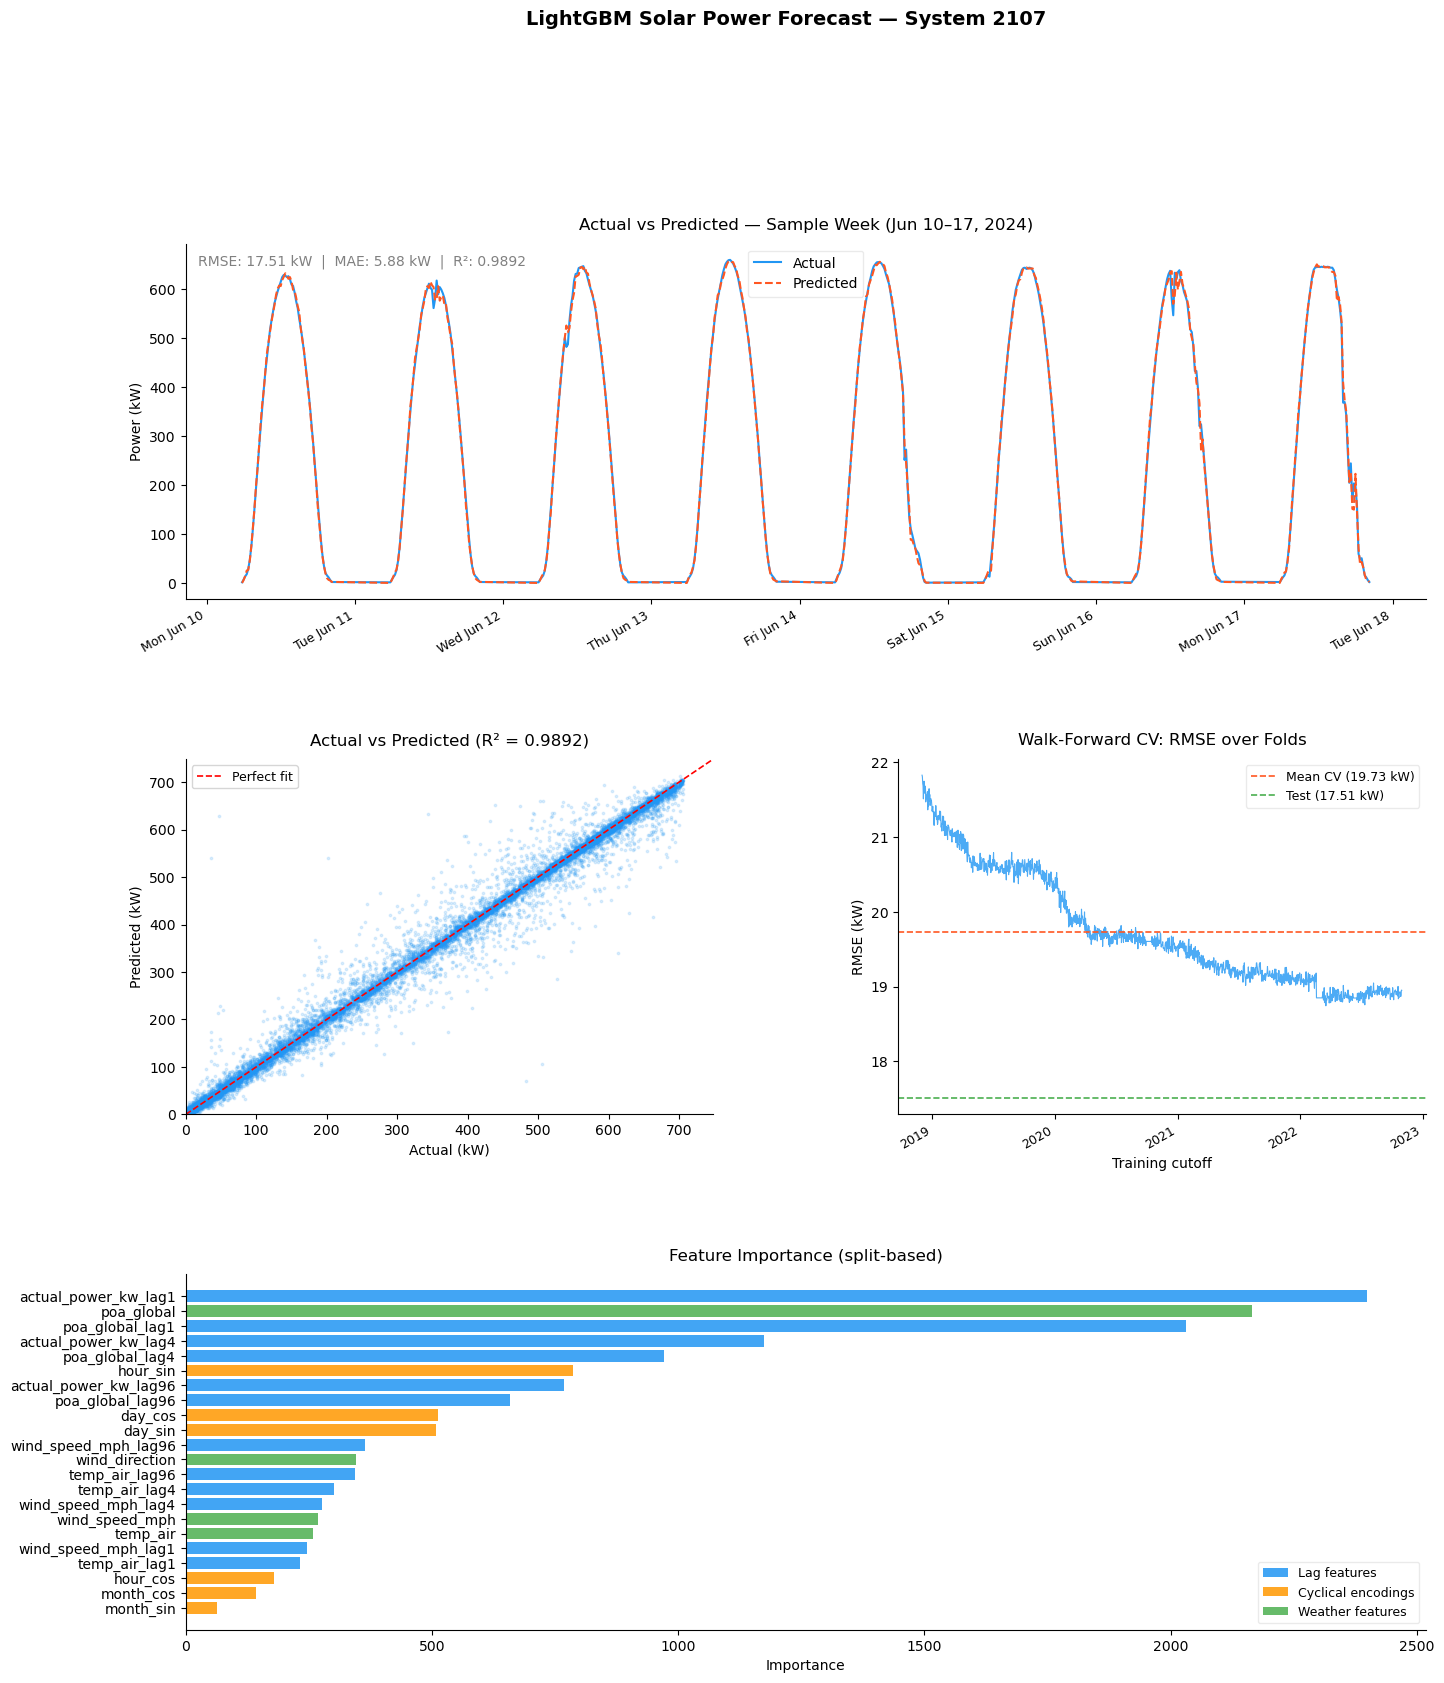

Saved → lgbm_results_clean.png


In [92]:
daytime = results_df[results_df["actual"] > 0]

# Pick one representative week in summer (peak solar)
week_start = "2024-06-10"
week_end   = "2024-06-17"
week = daytime[week_start:week_end]

fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── PLOT 1: ONE WEEK ACTUAL VS PREDICTED ─────────────────────────────────────

ax1 = fig.add_subplot(gs[0, :])  # full width
ax1.plot(week.index, week["actual"],    color="#2196F3", linewidth=1.5, label="Actual")
ax1.plot(week.index, week["predicted"], color="#FF5722", linewidth=1.5,
         linestyle="--", label="Predicted")
ax1.set_title("Actual vs Predicted — Sample Week (Jun 10–17, 2024)", fontsize=12, pad=10)
ax1.set_ylabel("Power (kW)", fontsize=10)
ax1.legend(fontsize=10, framealpha=0.4)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%a %b %d"))
ax1.xaxis.set_major_locator(mdates.DayLocator())
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)
ax1.annotate(f"RMSE: {test_rmse:.2f} kW  |  MAE: {test_mae:.2f} kW  |  R²: {test_r2:.4f}",
             xy=(0.01, 0.97), xycoords="axes fraction",
             fontsize=10, va="top", color="gray")

# ── PLOT 2: SCATTER ───────────────────────────────────────────────────────────

ax2 = fig.add_subplot(gs[1, 0])
ax2.scatter(daytime["actual"], daytime["predicted"],
            alpha=0.15, s=3, color="#2196F3")
lim = [0, max(daytime["actual"].max(), daytime["predicted"].max()) * 1.05]
ax2.plot(lim, lim, "r--", linewidth=1.2, label="Perfect fit")
ax2.set_title(f"Actual vs Predicted (R² = {test_r2:.4f})", fontsize=12, pad=10)
ax2.set_xlabel("Actual (kW)", fontsize=10)
ax2.set_ylabel("Predicted (kW)", fontsize=10)
ax2.set_xlim(lim)
ax2.set_ylim(lim)
ax2.legend(fontsize=9)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# ── PLOT 3: CV RMSE OVER FOLDS ────────────────────────────────────────────────

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(pd.to_datetime(scores_df["cutoff"]), scores_df["rmse"],
         color="#2196F3", linewidth=0.8, alpha=0.8)
ax3.axhline(scores_df["rmse"].mean(), color="#FF5722", linestyle="--",
            linewidth=1.2, label=f"Mean CV ({scores_df['rmse'].mean():.2f} kW)")
ax3.axhline(test_rmse, color="#4CAF50", linestyle="--",
            linewidth=1.2, label=f"Test ({test_rmse:.2f} kW)")
ax3.set_title("Walk-Forward CV: RMSE over Folds", fontsize=12, pad=10)
ax3.set_ylabel("RMSE (kW)", fontsize=10)
ax3.set_xlabel("Training cutoff", fontsize=10)
ax3.legend(fontsize=9, framealpha=0.4)
ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=30, ha="right", fontsize=9)

# ── PLOT 4: FEATURE IMPORTANCE ────────────────────────────────────────────────

ax4 = fig.add_subplot(gs[2, :])  # full width
importance_df = pd.DataFrame({
    "feature":    FEATURES,
    "importance": final_model.feature_importances_
}).sort_values("importance", ascending=True)

colors = ["#2196F3" if "lag" in f
          else "#FF9800" if any(x in f for x in ["sin", "cos"])
          else "#4CAF50"
          for f in importance_df["feature"]]

bars = ax4.barh(importance_df["feature"], importance_df["importance"],
                color=colors, alpha=0.85)
ax4.set_title("Feature Importance (split-based)", fontsize=12, pad=10)
ax4.set_xlabel("Importance", fontsize=10)
ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)

# Color legend for feature importance
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2196F3", alpha=0.85, label="Lag features"),
    Patch(facecolor="#FF9800", alpha=0.85, label="Cyclical encodings"),
    Patch(facecolor="#4CAF50", alpha=0.85, label="Weather features"),
]
ax4.legend(handles=legend_elements, fontsize=9, loc="lower right", framealpha=0.4)

plt.suptitle("LightGBM Solar Power Forecast — System 2107", fontsize=14,
             fontweight="bold", y=1.01)
plt.savefig("lgbm_results_clean.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → lgbm_results_clean.png")